In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def varying_retrieval_contexts(correctness_file, incorrectness_file):
    # 1. Load data
    df_corr = pd.read_csv(correctness_file, index_col=0)
    df_incorr = pd.read_csv(incorrectness_file, index_col=0)
    x_values = [int(col) for col in df_corr.columns]

    # 2. Set the style context
    # 'seaborn-v0_8-muted' or 'ggplot' provide better default colors
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Custom color palette for models
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    def style_subplot(ax, df, title, marker_type):
        for i, (model, scores) in enumerate(df.iterrows()):
            color = colors[i % len(colors)]
            ax.plot(x_values, scores, 
                    label=model, 
                    color=color,
                    marker=marker_type, 
                    markersize=8, 
                    linewidth=2.5,
                    markerfacecolor='white', # Hollow center look
                    markeredgewidth=2)
            
        ax.set_title(title, fontsize=20, fontweight='bold', pad=20, color='#333333')
        ax.set_xlabel('Number of Retrieval Contexts', fontsize=18, labelpad=10)
        ax.set_ylabel('%', fontsize=18, labelpad=10)
        ax.set_xticks(x_values)
        
        # Remove top and right borders (spines) for a cleaner look
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Customize grid
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)
        ax.grid(False, axis='x') # Usually cleaner without vertical grid lines
        
        # Legend styling
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best', fontsize = 16)

    # Plot both
    style_subplot(ax1, df_corr, 'Correctness', 'o')
    style_subplot(ax2, df_incorr, 'Incorrectness', 's')

    plt.tight_layout()
    plt.savefig('VaryingRetrievalContexts.pdf', bbox_inches='tight')
    plt.show()

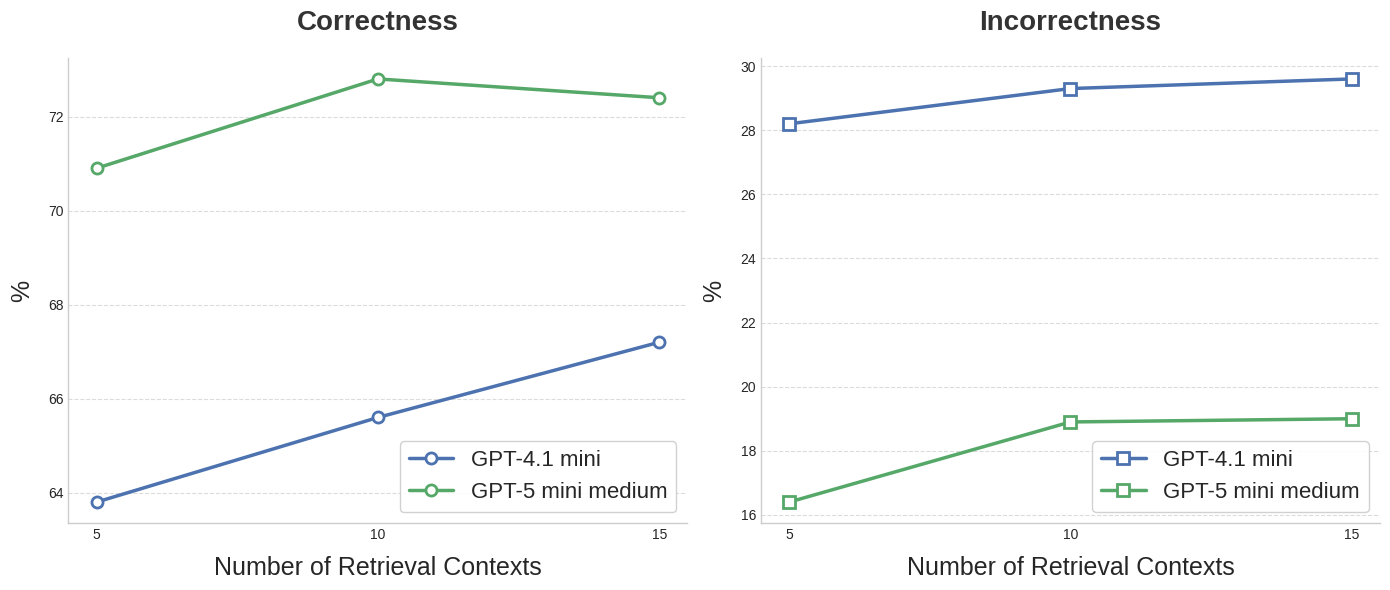

In [21]:
varying_retrieval_contexts("./data/varying_retrieval_contexts/correct.csv", "./data/varying_retrieval_contexts/incorrect.csv")